In [26]:
from sktime.datasets import load_tsf_to_dataframe
import pandas as pd
import matplotlib.pyplot as plt
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.utils import to_time_series_dataset
import numpy as np
from catboost import CatBoostRegressor

df, metadata = load_tsf_to_dataframe("./m4_yearly_dataset.tsf")

In [27]:
pd.set_option('display.max_rows', None)
print(df.head(36))
pd.reset_option('display.max_rows')

                                           series_value
series_name start_timestamp     timestamp              
T1          1979-01-01 12:00:00 0                5172.1
                                1                5133.5
                                2                5186.9
                                3                5084.6
                                4                5182.0
                                5                5414.3
                                6                5576.2
                                7                5752.9
                                8                5955.2
                                9                6087.8
                                10               6238.9
                                11               6317.2
                                12               6262.7
                                13               6361.0
                                14               6427.4
                                15              

In [28]:
df_reset = df.reset_index()
print(df_reset['series_name'].unique())

['T1' 'T2' 'T3' ... 'T22998' 'T22999' 'T23000']


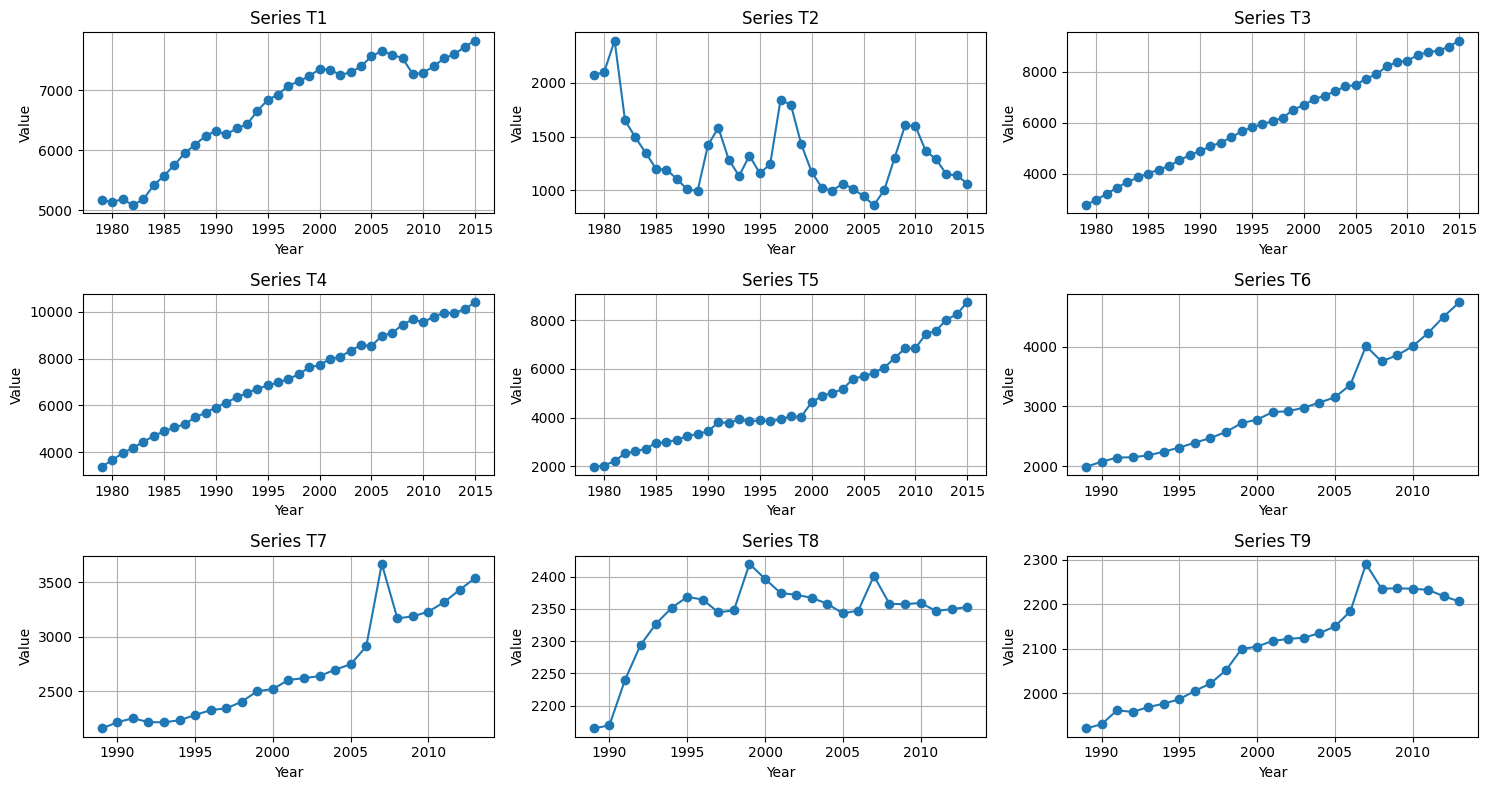

In [29]:
series_names = df_reset['series_name'].unique()[:9]

fig, axes = plt.subplots(3, 3, figsize=(15, 8))
axes = axes.flatten()

for i, name in enumerate(series_names):
    series_data = df_reset[df_reset['series_name'] == name].copy()
    start_year = pd.to_datetime(series_data['start_timestamp'].iloc[0]).year
    series_data['year'] = start_year + series_data['timestamp']
    
    axes[i].plot(series_data['year'], series_data['series_value'], marker='o', linestyle='-')
    axes[i].set_title(f'Series {name}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Value')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [31]:
grouped = df_reset.groupby('series_name')['series_value'].apply(list).reset_index()
grouped.columns = ['series_name', 'values']  

grouped = grouped[grouped['values'].apply(len) >= 40]

grouped = grouped.sort_values('series_name')

selected = grouped.head(150)

series_list = selected['values'].tolist()
series_names = selected['series_name'].tolist()

print(f"Отобрано {len(series_list)} рядов с длиной >= 40")
print("Минимальная длина среди отобранных:", min(len(v) for v in series_list))
print("Средняя длина среди отобранных:", np.mean([len(v) for v in series_list]))

Отобрано 150 рядов с длиной >= 40
Минимальная длина среди отобранных: 40
Средняя длина среди отобранных: 51.04666666666667


Обучаем модель с k=1...
Обучаем модель с k=2...
Обучаем модель с k=3...
Обучаем модель с k=4...
Обучаем модель с k=5...
Обучаем модель с k=6...
Обучаем модель с k=7...
Обучаем модель с k=8...
Обучаем модель с k=9...
Обучаем модель с k=10...


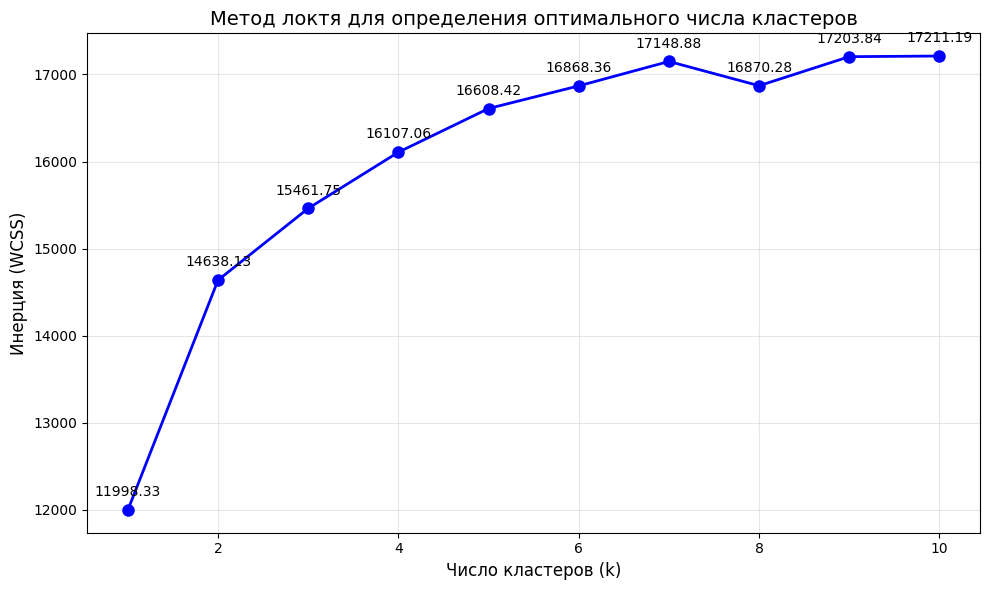


Таблица инерции по числу кластеров:
k	Инерция
1	11998.33
2	14638.13
3	15461.75
4	16107.06
5	16608.42
6	16868.36
7	17148.88
8	16870.28
9	17203.84
10	17211.19


In [32]:
X = to_time_series_dataset(series_list)
X_scaled = TimeSeriesScalerMeanVariance().fit_transform(X)

k_range = range(1, 11)
inertias = []

for k in k_range:
    print(f"Обучаем модель с k={k}...")

    km = TimeSeriesKMeans(
        n_clusters=k,
        metric="softdtw",
        max_iter=50,
        max_iter_barycenter=10,
        random_state=0,
        verbose=0
    ).fit(X_scaled)

    inertias.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Число кластеров (k)', fontsize=12)
plt.ylabel('Инерция (WCSS)', fontsize=12)
plt.title('Метод локтя для определения оптимального числа кластеров', fontsize=14)
plt.grid(True, alpha=0.3)

for i, inertia in enumerate(inertias):
    plt.annotate(f'{inertia:.2f}', (k_range[i], inertia),
                 textcoords="offset points", xytext=(0, 10), ha='center')

plt.tight_layout()
plt.show()

print("\nТаблица инерции по числу кластеров:")
print("k\tИнерция")
for k, inertia in zip(k_range, inertias):
    print(f"{k}\t{inertia:.2f}")


In [33]:
km_dba = TimeSeriesKMeans(
    n_clusters=9,
    metric="softdtw",
    max_iter=5,
    max_iter_barycenter=5,
    random_state=0
).fit(X_scaled)

cluster_labels = km_dba.labels_
print("Метки кластеров:", cluster_labels)

Метки кластеров: [3 5 5 1 5 1 5 7 2 5 8 6 3 4 1 1 5 1 5 8 5 5 7 7 5 5 8 7 1 5 0 8 0 2 1 1 7
 6 1 7 5 2 1 0 0 8 3 0 7 5 8 2 1 1 3 1 0 3 5 1 8 1 8 3 5 8 6 1 1 5 5 1 1 6
 5 0 1 1 8 5 1 6 0 3 3 2 1 1 5 2 7 5 6 1 5 5 6 8 5 5 8 3 6 5 7 5 2 5 7 6 6
 1 5 5 2 7 8 5 8 5 5 8 2 2 7 5 5 5 5 2 5 8 5 8 2 5 5 5 5 2 2 5 5 2 8 5 8 1
 5 2]


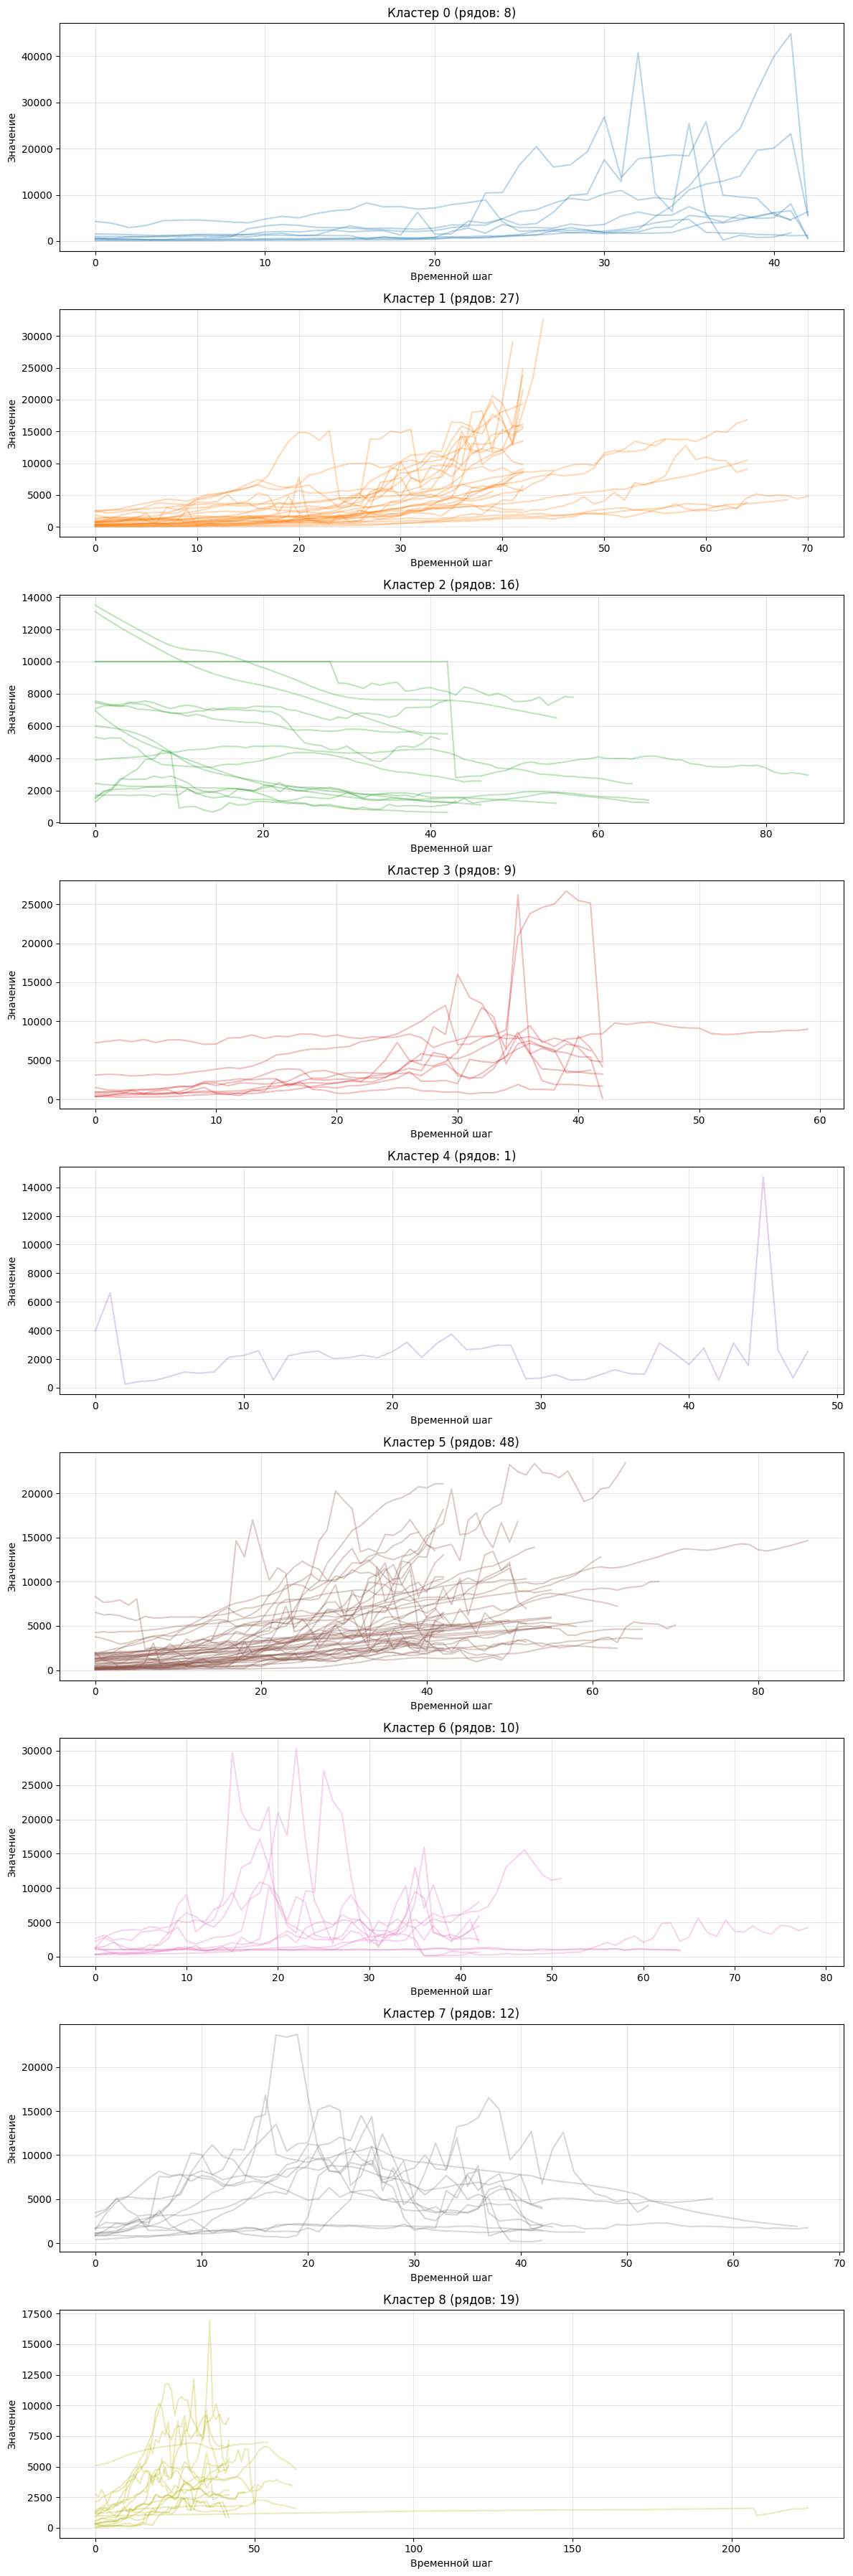

In [37]:
centroids = km_dba.cluster_centers_
n_clusters = len(centroids)

fig, axes = plt.subplots(n_clusters, 1, figsize=(12, 4 * n_clusters))
if n_clusters == 1:
    axes = [axes]

for cluster_id in range(n_clusters):
    ax = axes[cluster_id]    
    cluster_indices = np.where(cluster_labels == cluster_id)[0]
    for idx in cluster_indices:
        series_values = series_list[idx]   # значения ряда
        ax.plot(series_values, alpha=0.3, color=f'C{cluster_id}')
    
    ax.set_title(f'Кластер {cluster_id} (рядов: {len(cluster_indices)})')
    ax.set_xlabel('Временной шаг')
    ax.set_ylabel('Значение')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
import numpy as np

def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred)))

naive_smape_list = []
for values in series_list:
    train = values[:-6]
    test = values[-6:]
    naive_forecast = np.full(6, train[-1])  
    naive_smape_list.append(smape(test, naive_forecast))

unique_clusters = np.unique(cluster_labels)
for cl in unique_clusters:
    indices = np.where(cluster_labels == cl)[0]
    smapes_cluster = [naive_smape_list[i] for i in indices]
    mean_smape = np.mean(smapes_cluster)
    lengths_cluster = [len(series_list[i]) for i in indices]  
    mean_length = np.mean(lengths_cluster) 
    
    print(f"Кластер {cl}: {len(indices)} рядов, средний Naïve sMAPE = {mean_smape:.2f}, средняя длина ряда = {mean_length:.1f}")


Кластер 0: 8 рядов, средний Naïve sMAPE = 74.89, средняя длина ряда = 42.8
Кластер 1: 27 рядов, средний Naïve sMAPE = 25.62, средняя длина ряда = 48.8
Кластер 2: 16 рядов, средний Naïve sMAPE = 8.76, средняя длина ряда = 52.8
Кластер 3: 9 рядов, средний Naïve sMAPE = 56.88, средняя длина ряда = 44.7
Кластер 4: 1 рядов, средний Naïve sMAPE = 119.20, средняя длина ряда = 49.0
Кластер 5: 48 рядов, средний Naïve sMAPE = 14.49, средняя длина ряда = 51.9
Кластер 6: 10 рядов, средний Naïve sMAPE = 47.52, средняя длина ряда = 51.9
Кластер 7: 12 рядов, средний Naïve sMAPE = 40.86, средняя длина ряда = 49.7
Кластер 8: 19 рядов, средний Naïve sMAPE = 20.73, средняя длина ряда = 57.7


In [45]:
H = 6
L = 35
min_lags = L
max_lags = 80


lengths = [len(v) for v in series_list]
N_min = np.min(lengths)
print(f"Минимальная длина ряда: {N_min}")

X_train = []
y_train = []
rows_used_for_train = set()

for idx, values in enumerate(series_list):
    cluster = cluster_labels[idx]
    N = len(values)
    if N >= L + H:
        rows_used_for_train.add(idx)
        for t in range(L, N - H + 1):
            feats = values[t-L:t].copy()
            feats_with_cluster = np.append(feats, cluster)
            X_train.append(feats_with_cluster)
            y_train.append(values[t:t+H])  

X_train = np.array(X_train)
y_train = np.array(y_train)
print(f"Рядов, участвовавших в обучении: {len(rows_used_for_train)} из {len(series_list)}")

feature_names = [f'lag_{i}' for i in range(L)] + ['cluster']
df_train = pd.DataFrame(X_train, columns=feature_names)
df_train['cluster'] = df_train['cluster'].astype(int)

model = CatBoostRegressor(
    loss_function='MultiRMSE',
    iterations=1500,
    learning_rate=0.1,
    depth=6,
    cat_features=['cluster'],
    verbose=50,
    random_seed=42
)

model.fit(df_train, y_train)

catboost_smape_list = []
predictions_list = []
true_list = []
row_index_list = []
cluster_for_plot = []
rows_tested = 0

for idx, values in enumerate(series_list):
    cluster = cluster_labels[idx]
    N = len(values)
    if N >= L + H:
        rows_tested += 1
        test_feats = values[N-H-L:N-H].copy()
        test_feats_with_cluster = np.append(test_feats, cluster).reshape(1, -1)

        df_test = pd.DataFrame(test_feats_with_cluster, columns=feature_names)
        df_test['cluster'] = df_test['cluster'].astype(int)

        pred = model.predict(df_test).flatten()
        true = values[N-H:] 

        smape_val = 100 * np.mean(2 * np.abs(true - pred) / (np.abs(true) + np.abs(pred)))
        catboost_smape_list.append(smape_val)

        predictions_list.append(pred)
        true_list.append(true)
        row_index_list.append(idx)
        cluster_for_plot.append(cluster)
    else:
        catboost_smape_list.append(np.nan)

print(f"Рядов, протестированных CatBoost: {rows_tested} из {len(series_list)}")

Минимальная длина ряда: 40
Рядов, участвовавших в обучении: 146 из 150
0:	learn: 9876.0479138	total: 59.5ms	remaining: 1m 29s
50:	learn: 3488.7904082	total: 3.24s	remaining: 1m 32s
100:	learn: 2706.8362200	total: 6.44s	remaining: 1m 29s
150:	learn: 2280.1114246	total: 9.55s	remaining: 1m 25s
200:	learn: 1994.4565866	total: 13s	remaining: 1m 24s
250:	learn: 1779.0505029	total: 16.4s	remaining: 1m 21s
300:	learn: 1582.2109540	total: 19.4s	remaining: 1m 17s
350:	learn: 1420.8092161	total: 22.5s	remaining: 1m 13s
400:	learn: 1296.3043995	total: 25.5s	remaining: 1m 9s
450:	learn: 1198.1122182	total: 28.6s	remaining: 1m 6s
500:	learn: 1109.9156818	total: 31.7s	remaining: 1m 3s
550:	learn: 1027.2885317	total: 34.9s	remaining: 1m
600:	learn: 956.7909202	total: 37.9s	remaining: 56.7s
650:	learn: 896.6988332	total: 41s	remaining: 53.4s
700:	learn: 838.6763924	total: 43.9s	remaining: 50s
750:	learn: 786.6046987	total: 46.8s	remaining: 46.7s
800:	learn: 742.4934258	total: 49.8s	remaining: 43.5s
85

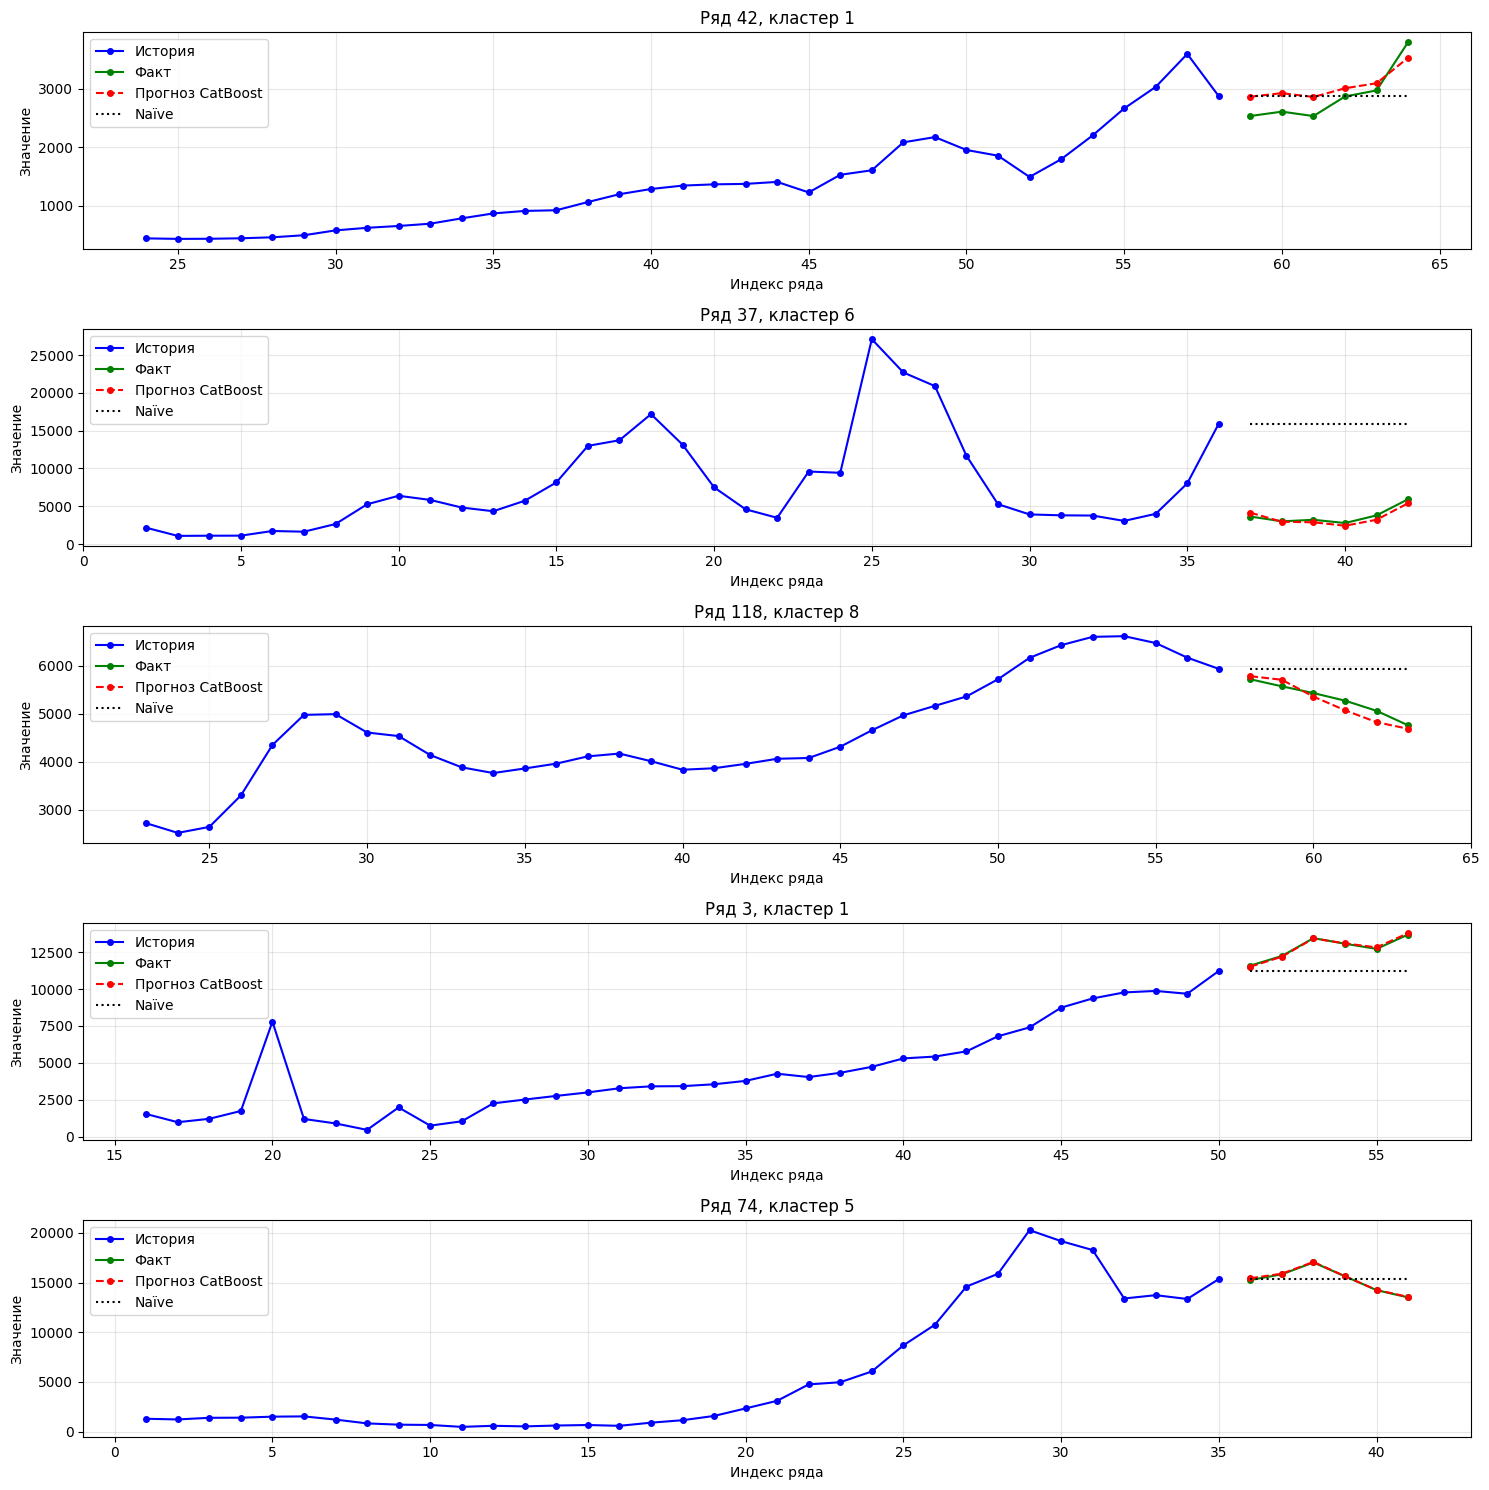

CatBoost sMAPE по кластерам:
Кластер 0: 8 рядов из 8, средний CatBoost sMAPE = 27.13
Кластер 1: 26 рядов из 27, средний CatBoost sMAPE = 3.45
Кластер 2: 15 рядов из 16, средний CatBoost sMAPE = 7.30
Кластер 3: 9 рядов из 9, средний CatBoost sMAPE = 15.43
Кластер 4: 1 рядов из 1, средний CatBoost sMAPE = 30.40
Кластер 5: 46 рядов из 48, средний CatBoost sMAPE = 3.30
Кластер 6: 10 рядов из 10, средний CatBoost sMAPE = 9.52
Кластер 7: 12 рядов из 12, средний CatBoost sMAPE = 12.19
Кластер 8: 19 рядов из 19, средний CatBoost sMAPE = 4.41


In [46]:
if len(predictions_list) > 0:
    n_plots = min(5, len(predictions_list))
    sample_indices = random.sample(range(len(predictions_list)), n_plots)

    plt.figure(figsize=(15, 3 * n_plots))
    for i, idx_in_list in enumerate(sample_indices):
        plot_idx = row_index_list[idx_in_list]
        cluster_id = cluster_for_plot[idx_in_list]
        true_vals = true_list[idx_in_list]
        pred_vals = predictions_list[idx_in_list]

        values = series_list[plot_idx]
        N = len(values)

        hist_indices = list(range(N - 6 - L, N - 6))
        history = values[N - 6 - L:N - 6]
        test_indices = list(range(N - 6, N))

        plt.subplot(n_plots, 1, i + 1)
        plt.plot(hist_indices, history, 'b-o', label='История', markersize=4)
        plt.plot(test_indices, true_vals, 'g-o', label='Факт', markersize=4)
        plt.plot(test_indices, pred_vals, 'r--o', label='Прогноз CatBoost', markersize=4)
        naive = [history[-1]] * 6
        plt.plot(test_indices, naive, 'k:', label='Naïve', markersize=4)

        plt.title(f'Ряд {plot_idx}, кластер {cluster_id}')
        plt.xlabel('Индекс ряда')
        plt.ylabel('Значение')
        plt.legend()
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Нет данных для визуализации прогнозов")


unique_clusters = np.unique(cluster_labels)
print("CatBoost sMAPE по кластерам:")
for cl in unique_clusters:
    indices = np.where(cluster_labels == cl)[0]
    valid_smapes = [catboost_smape_list[i] for i in indices if not np.isnan(catboost_smape_list[i])]
    if len(valid_smapes) > 0:
        mean_smape = np.mean(valid_smapes)
        print(f"Кластер {cl}: {len(valid_smapes)} рядов из {len(indices)}, средний CatBoost sMAPE = {mean_smape:.2f}")
    else:
        print(f"Кластер {cl}: нет данных для расчёта")